## Wine Data analysis

* Vehicle dataset: https://archive.ics.uci.edu/dataset/109/wine
* 178 instances, 13 Features
* Objective: Segmenting wines based on their features similarities by leveraging unsupervised K-means modelling approach.

In [162]:
# Imports
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns


In [163]:
#Loading Files
df = pd.read_csv('Unit06_wine.csv')
df.head()

,Wine,Alcohol,Malic.acid,Ash,Acl,Mg,Phenols,Flavanoids,Nonflavanoid.phenols,Proanth,Color.int,Hue,OD,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


In [164]:
df.tail()

,Wine,Alcohol,Malic.acid,Ash,Acl,Mg,Phenols,Flavanoids,Nonflavanoid.phenols,Proanth,Color.int,Hue,OD,Proline
173,3,13.71,5.65,2.45,20.5,95,1.68,0.61,0.52,1.06,7.7,0.64,1.74,740
174,3,13.40,3.91,2.48,23.0,102,1.80,0.75,0.43,1.41,7.3,0.70,1.56,750
175,3,13.27,4.28,2.26,20.0,120,1.59,0.69,0.43,1.35,10.2,0.59,1.56,835
176,3,13.17,2.59,2.37,20.0,120,1.65,0.68,0.53,1.46,9.3,0.60,1.62,840
177,3,14.13,4.10,2.74,24.5,96,2.05,0.76,0.56,1.35,9.2,0.61,1.60,560


## 1.  Data Overview

In [165]:
# 1.1 Dataset dimensions
df.shape

(178, 14)

In [166]:
# 1.2 Variable types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Wine                  178 non-null    int64  
 1   Alcohol               178 non-null    float64
 2   Malic.acid            178 non-null    float64
 3   Ash                   178 non-null    float64
 4   Acl                   178 non-null    float64
 5   Mg                    178 non-null    int64  
 6   Phenols               178 non-null    float64
 7   Flavanoids            178 non-null    float64
 8   Nonflavanoid.phenols  178 non-null    float64
 9   Proanth               178 non-null    float64
 10  Color.int             178 non-null    float64
 11  Hue                   178 non-null    float64
 12  OD                    178 non-null    float64
 13  Proline               178 non-null    int64  
dtypes: float64(11), int64(3)
memory usage: 19.6 KB


## 2. Data Quality Assessment & Cleaning
Purpose: Assessing the completeness, consistency and plausibility of the data by identifying missing values, duplicates, suspicious values and potential outliers that may require further investigation before modelling.

In [167]:
# High level overview (can replace below)
overview = pd.DataFrame({

    'Data Type': df.dtypes,
    'Non-Null': df.notnull().sum(),
    'Missing': df.isnull().sum(),
    'Missing %': df.isnull().mean() * 100,
    'Unique': df.nunique()

})

overview

,Data Type,Non-Null,Missing,Missing %,Unique
Wine,int64,178,0,0.0,3
Alcohol,float64,178,0,0.0,126
Malic.acid,float64,178,0,0.0,133
Ash,float64,178,0,0.0,79
Acl,float64,178,0,0.0,63
Mg,int64,178,0,0.0,53
Phenols,float64,178,0,0.0,97
Flavanoids,float64,178,0,0.0,132
Nonflavanoid.phenols,float64,178,0,0.0,39
Proanth,float64,178,0,0.0,101


In [168]:
# Duplicates
df.duplicated().sum()

np.int64(0)

In [169]:
#Unique values aacross numerical atrributes
df.select_dtypes(include='number').nunique().sort_values()

Wine                      3
Nonflavanoid.phenols     39
Mg                       53
Acl                      63
Hue                      78
Ash                      79
Phenols                  97
Proanth                 101
Proline                 121
OD                      122
Alcohol                 126
Flavanoids              132
Color.int               132
Malic.acid              133
dtype: int64

* Dataset contains 178 observations and 13 numerical attributes, all continuous variables, with the exception of Wine as an encoded numercial category.
* Dataset has no missing values and contains no duplicates; data is high cardinality, with the exception of a few attributes such as NonFlavanoid. phenols, Mg. Acl, Hue, which are more common across this dataset.

In [ ]:
# Excluding Wine feature to not influence my clustering outcome

df_wine_clean = df.copy() 

features = df_wine_clean.columns.drop('Wine')

df_wine_clean[features]

,Alcohol,Malic.acid,Ash,Acl,Mg,Phenols,Flavanoids,Nonflavanoid.phenols,Proanth,Color.int,Hue,OD,Proline
0,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735
...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,13.71,5.65,2.45,20.5,95,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740
174,13.40,3.91,2.48,23.0,102,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750
175,13.27,4.28,2.26,20.0,120,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835
176,13.17,2.59,2.37,20.0,120,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840


## 3. Exploratory Data Analysis

In [171]:
df[features].describe().T

,count,mean,std,min,25%,50%,75%,max
Alcohol,178.0,13.000618,0.811827,11.03,12.3625,13.050,13.6775,14.83
Malic.acid,178.0,2.336348,1.117146,0.74,1.6025,1.865,3.0825,5.80
Ash,178.0,2.366517,0.274344,1.36,2.2100,2.360,2.5575,3.23
Acl,178.0,19.494944,3.339564,10.60,17.2000,19.500,21.5000,30.00
Mg,178.0,99.741573,14.282484,70.00,88.0000,98.000,107.0000,162.00
Phenols,178.0,2.295112,0.625851,0.98,1.7425,2.355,2.8000,3.88
Flavanoids,178.0,2.029270,0.998859,0.34,1.2050,2.135,2.8750,5.08
Nonflavanoid.phenols,178.0,0.361854,0.124453,0.13,0.2700,0.340,0.4375,0.66
Proanth,178.0,1.590899,0.572359,0.41,1.2500,1.555,1.9500,3.58
Color.int,178.0,5.058090,2.318286,1.28,3.2200,4.690,6.2000,13.00


<function matplotlib.pyplot.show(close=None, block=None)>

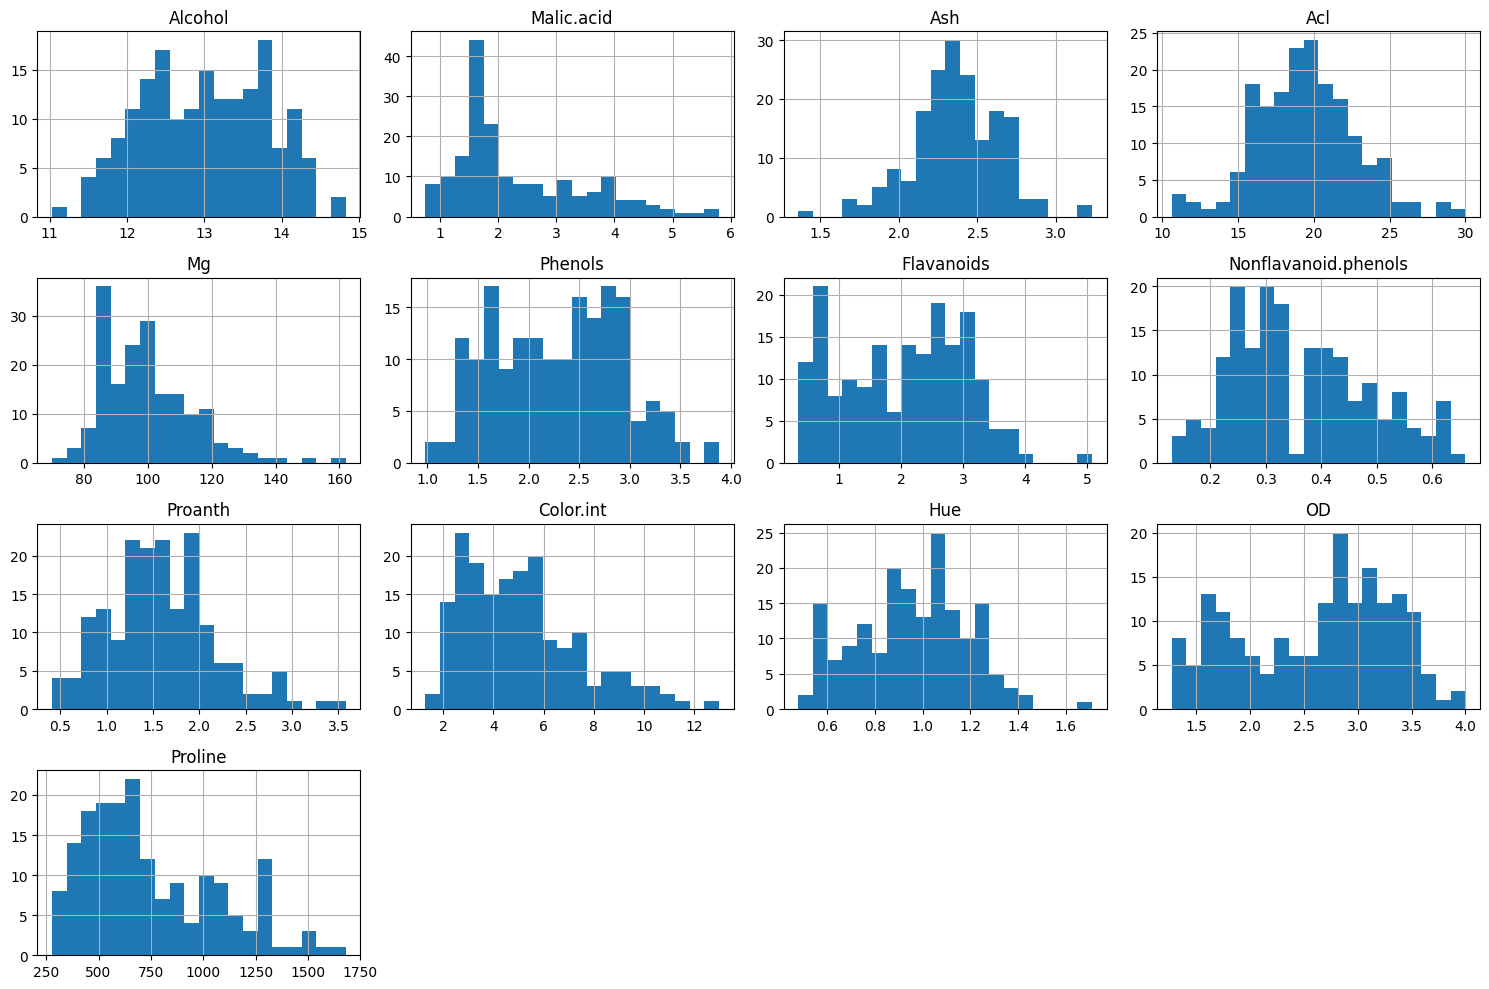

In [172]:
#Distribution
df[features].hist(
    figsize=(15, 10), 
    bins = 20
)

plt.tight_layout()
plt.show

Observation: 
* The majority of attributes show an approximately symmetric distribution, with the exception of Proline, Color.int, Malic.acid, Mg, which show noticeable right skewness. There are several high-value observations across Hue, Mg, and Ash. The attributes differ in their dispersion and numerical ranges. 
The differences in feature scale will need to be addressed before applying distance-based K-means clustering, as Euclidean distance would be influenced by large-scale features such as Proline.

Action points: 
* Skewness and High values -> to be investigated
* Different scales -> standardise for K_means


In [173]:
# Skewness (assymetrie)
skewness = df_wine_clean[features].skew().sort_values(ascending=False)

skewness

Mg                      1.098191
Malic.acid              1.039651
Color.int               0.868585
Proline                 0.767822
Proanth                 0.517137
Nonflavanoid.phenols    0.450151
Acl                     0.213047
Phenols                 0.086639
Flavanoids              0.025344
Hue                     0.021091
Alcohol                -0.051482
Ash                    -0.176699
OD                     -0.307285
dtype: float64

In [174]:
# Kurtosis (tail heaviness, extreme value tendency)
kurtosis = df_wine_clean[features].kurt().sort_values(ascending=False)

kurtosis

Mg                      2.104991
Ash                     1.143978
Proanth                 0.554649
Acl                     0.487942
Color.int               0.381522
Malic.acid              0.299207
Proline                -0.248403
Hue                    -0.344096
Nonflavanoid.phenols   -0.637191
Phenols                -0.835627
Alcohol                -0.852500
Flavanoids             -0.880382
OD                     -1.086435
dtype: float64

* Skewness: Mg, Malic.acid, Color.int. Proline - confirms moderate to strong right skewness (>0.5), whereas other attributes are approximately symmetric in their distribition with only light skewness.
* Kurtosis: Mg, Ash, OD show more high-value observations.   

**EDA summary:**
* The majority of attributes show approximately symmetric distribution or only light skewness. Mg, Malic.acid, Color.int and Proline show noticeable right skewness. Higher value observations are visible in several variables (Proline, Color.int, Mg), while kurtosis is particularly positive for Mg, Ash, indicating heavier tails. Several attributes show negative kurtosis and a flatter distribution. The attributes differ in their dispersion and numerical ranges. 




## 4. Attributes Inspection on high-value observations 
* Investigate whether removal or transformation for Mg, Malic.acid., Color.int, Proline is requiered.

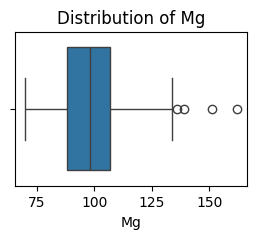

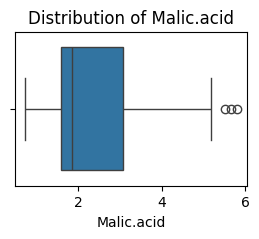

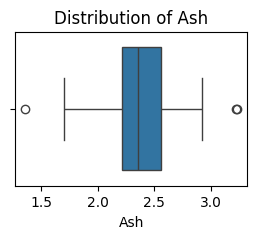

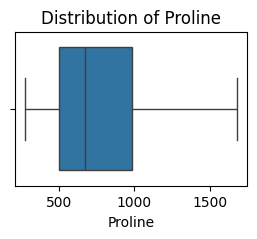

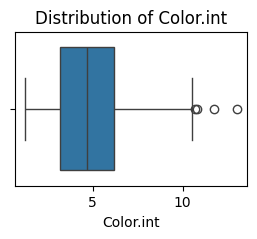

In [175]:
attributes_to_check = ['Mg', 'Malic.acid','Ash', 'Proline', 'Color.int'] 

for col in attributes_to_check:
    plt.figure(figsize=(3,2))

    sns.boxplot(
        x = df_wine_clean[col]
    )

    plt.title(f'Distribution of {col}')
    plt.show()

In [176]:
# Investigating Mg 
df_wine_clean['Mg'].describe(
    percentiles=[0.90, 0.95, 0.99])

count    178.000000
mean      99.741573
std       14.282484
min       70.000000
50%       98.000000
90%      118.000000
95%      124.300000
99%      141.760000
max      162.000000
Name: Mg, dtype: float64

In [177]:
df_wine_clean.nlargest(5,'Mg')

,Wine,Alcohol,Malic.acid,Ash,Acl,Mg,Phenols,Flavanoids,Nonflavanoid.phenols,Proanth,Color.int,Hue,OD,Proline
95,2,12.47,1.52,2.20,19.0,162,2.50,2.27,0.32,3.28,2.60,1.16,2.63,937
69,2,12.21,1.19,1.75,16.8,151,1.85,1.28,0.14,2.50,2.85,1.28,3.07,718
73,2,12.99,1.67,2.60,30.0,139,3.30,2.89,0.21,1.96,3.35,1.31,3.50,985
78,2,12.33,0.99,1.95,14.8,136,1.90,1.85,0.35,2.76,3.40,1.06,2.31,750
96,2,11.81,2.12,2.74,21.5,134,1.60,0.99,0.14,1.56,2.50,0.95,2.26,625


In [178]:
# Investigating Malic.acid 
df_wine_clean['Malic.acid'].describe(
    percentiles=[0.90, 0.95, 0.99])

count    178.000000
mean       2.336348
std        1.117146
min        0.740000
50%        1.865000
90%        3.983000
95%        4.455500
99%        5.542200
max        5.800000
Name: Malic.acid, dtype: float64

In [179]:
df_wine_clean.nlargest(5,'Malic.acid')

,Wine,Alcohol,Malic.acid,Ash,Acl,Mg,Phenols,Flavanoids,Nonflavanoid.phenols,Proanth,Color.int,Hue,OD,Proline
123,2,13.05,5.80,2.13,21.5,86,2.62,2.65,0.30,2.01,2.6,0.73,3.10,380
173,3,13.71,5.65,2.45,20.5,95,1.68,0.61,0.52,1.06,7.7,0.64,1.74,740
137,3,12.53,5.51,2.64,25.0,96,1.79,0.60,0.63,1.10,5.0,0.82,1.69,515
155,3,13.17,5.19,2.32,22.0,93,1.74,0.63,0.61,1.55,7.9,0.60,1.48,725
146,3,13.88,5.04,2.23,20.0,80,0.98,0.34,0.40,0.68,4.9,0.58,1.33,415


In [180]:
# Investigating Ash
df_wine_clean['Ash'].describe(
    percentiles=[0.01, 0.05, 0.90, 0.95, 0.99])

count    178.000000
mean       2.366517
std        0.274344
min        1.360000
1%         1.700000
5%         1.920000
50%        2.360000
90%        2.700000
95%        2.741500
99%        2.989000
max        3.230000
Name: Ash, dtype: float64

In [181]:
df_wine_clean.nlargest(5,'Ash')

,Wine,Alcohol,Malic.acid,Ash,Acl,Mg,Phenols,Flavanoids,Nonflavanoid.phenols,Proanth,Color.int,Hue,OD,Proline
121,2,11.56,2.05,3.23,28.5,119,3.18,5.08,0.47,1.87,6.00,0.93,3.69,465
25,1,13.05,2.05,3.22,25.0,124,2.63,2.68,0.47,1.92,3.58,1.13,3.20,830
112,2,11.76,2.68,2.92,20.0,103,1.75,2.03,0.60,1.05,3.80,1.23,2.50,607
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735
169,3,13.40,4.60,2.86,25.0,112,1.98,0.96,0.27,1.11,8.50,0.67,1.92,630


In [182]:
df_wine_clean.nsmallest(5,'Ash')

,Wine,Alcohol,Malic.acid,Ash,Acl,Mg,Phenols,Flavanoids,Nonflavanoid.phenols,Proanth,Color.int,Hue,OD,Proline
59,2,12.37,0.94,1.36,10.6,88,1.98,0.57,0.28,0.42,1.95,1.05,1.82,520
66,2,13.11,1.01,1.70,15.0,78,2.98,3.18,0.26,2.28,5.30,1.12,3.18,502
100,2,12.08,2.08,1.70,17.5,97,2.23,2.17,0.26,1.40,3.30,1.27,2.96,710
76,2,13.03,0.90,1.71,16.0,86,1.95,2.03,0.24,1.46,4.60,1.19,2.48,392
69,2,12.21,1.19,1.75,16.8,151,1.85,1.28,0.14,2.50,2.85,1.28,3.07,718


In [183]:
# Investigating Proline 
df_wine_clean['Proline'].describe(
    percentiles=[0.90, 0.95, 0.99])

count     178.000000
mean      746.893258
std       314.907474
min       278.000000
50%       673.500000
90%      1261.500000
95%      1297.250000
99%      1522.360000
max      1680.000000
Name: Proline, dtype: float64

In [184]:
df_wine_clean.nlargest(5,'Proline')

,Wine,Alcohol,Malic.acid,Ash,Acl,Mg,Phenols,Flavanoids,Nonflavanoid.phenols,Proanth,Color.int,Hue,OD,Proline
18,1,14.19,1.59,2.48,16.5,108,3.30,3.93,0.32,1.86,8.70,1.23,2.82,1680
14,1,14.38,1.87,2.38,12.0,102,3.30,3.64,0.29,2.96,7.50,1.20,3.00,1547
31,1,13.58,1.66,2.36,19.1,106,2.86,3.19,0.22,1.95,6.90,1.09,2.88,1515
10,1,14.10,2.16,2.30,18.0,105,2.95,3.32,0.22,2.38,5.75,1.25,3.17,1510
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480


In [185]:
# Investigating Color.int 
df_wine_clean['Color.int'].describe(
    percentiles=[0.90, 0.95, 0.99])

count    178.000000
mean       5.058090
std        2.318286
min        1.280000
50%        4.690000
90%        8.530000
95%        9.598000
99%       11.018500
max       13.000000
Name: Color.int, dtype: float64

In [186]:
df_wine_clean.nlargest(5,'Color.int')

,Wine,Alcohol,Malic.acid,Ash,Acl,Mg,Phenols,Flavanoids,Nonflavanoid.phenols,Proanth,Color.int,Hue,OD,Proline
158,3,14.34,1.68,2.70,25.0,98,2.80,1.31,0.53,2.70,13.00,0.57,1.96,660
159,3,13.48,1.67,2.64,22.5,89,2.60,1.10,0.52,2.29,11.75,0.57,1.78,620
151,3,12.79,2.67,2.48,22.0,112,1.48,1.36,0.24,1.26,10.80,0.48,1.47,480
166,3,13.45,3.70,2.60,23.0,111,1.70,0.92,0.43,1.46,10.68,0.85,1.56,695
153,3,13.23,3.30,2.28,18.5,98,1.80,0.83,0.61,1.87,10.52,0.56,1.51,675


**Conclusion:** 
Features that were identified through skewness and kurtosis and boxplots were examined using percentile values. 
All investigated variables with high-value observations appear to form plausible tail values, progressively increasing, rather than extreme outliers. These values represent plausible tails, so no removal is required. 

## 5. Relationships


In [187]:
# Correlation analysis among continious variables

corr_matrix = df_wine_clean[features].corr()

corr_matrix.round(2)

,Alcohol,Malic.acid,Ash,Acl,Mg,Phenols,Flavanoids,Nonflavanoid.phenols,Proanth,Color.int,Hue,OD,Proline
Alcohol,1.00,0.09,0.21,-0.31,0.27,0.29,0.24,-0.16,0.14,0.55,-0.07,0.07,0.64
Malic.acid,0.09,1.00,0.16,0.29,-0.05,-0.34,-0.41,0.29,-0.22,0.25,-0.56,-0.37,-0.19
Ash,0.21,0.16,1.00,0.44,0.29,0.13,0.12,0.19,0.01,0.26,-0.07,0.00,0.22
Acl,-0.31,0.29,0.44,1.00,-0.08,-0.32,-0.35,0.36,-0.20,0.02,-0.27,-0.28,-0.44
Mg,0.27,-0.05,0.29,-0.08,1.00,0.21,0.20,-0.26,0.24,0.20,0.06,0.07,0.39
Phenols,0.29,-0.34,0.13,-0.32,0.21,1.00,0.86,-0.45,0.61,-0.06,0.43,0.70,0.50
Flavanoids,0.24,-0.41,0.12,-0.35,0.20,0.86,1.00,-0.54,0.65,-0.17,0.54,0.79,0.49
Nonflavanoid.phenols,-0.16,0.29,0.19,0.36,-0.26,-0.45,-0.54,1.00,-0.37,0.14,-0.26,-0.50,-0.31
Proanth,0.14,-0.22,0.01,-0.20,0.24,0.61,0.65,-0.37,1.00,-0.03,0.30,0.52,0.33
Color.int,0.55,0.25,0.26,0.02,0.20,-0.06,-0.17,0.14,-0.03,1.00,-0.52,-0.43,0.32


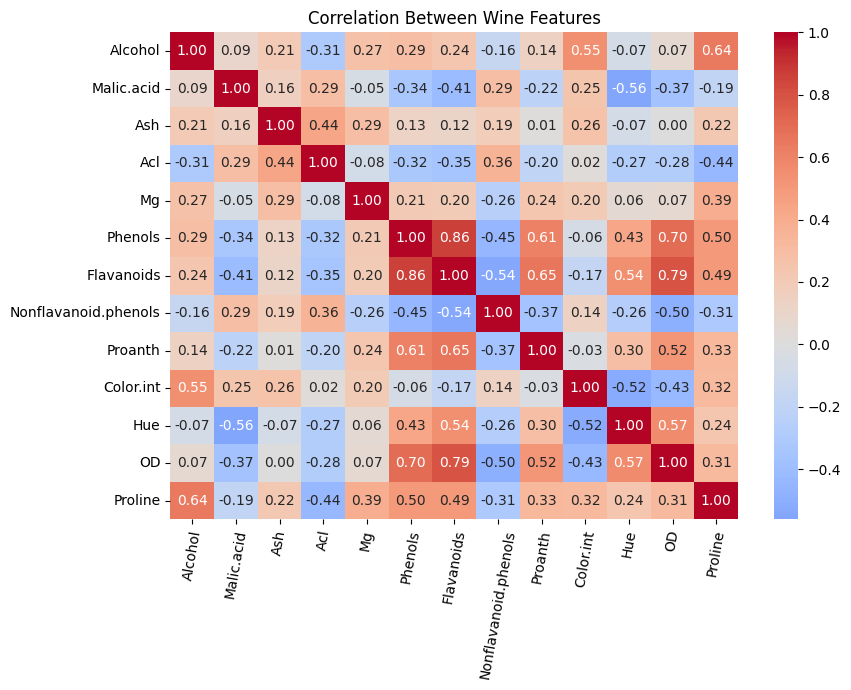

In [211]:
#Visualise correlation - Correlaction Heatmap
plt.figure(figsize=(9, 7))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0
)
plt.xticks(rotation=80)
plt.title('Correlation Between Wine Features')

plt.tight_layout()
plt.show()

A moderate-strongest positive correlations are obsvered between attributes:
- Flavonoids vs Phenols (0.86)
- Flavonoids vs OD (0.79)
- Flavonoids vs Pronath (0.65)
- Phenols vs OD (0.70)
- Phenols vs Pronath (0.61) 
- Alcohol vs Proline (0.64)

A moderate negative correlations are obsvered between attributes:
- Flavonoids vs Nonfalvonoid (-0.54)
- Phenols vs Nonfalvonoid (-0.45)
- Hue vs Color.int (-0.52)
- OD vs Color.int (-0.43)

The correlation heatmap indicates that there is a correleation between a group: Phenols vs Flavonoids vs OD vs Pronath which may suggest a potential redundancy of one of the attributes. However, no features are removed yet. 

## 6. Features Standardisation
Given that the numerical features substantially differ in scale a standardisation is requiered before applying distance-based K-Means, to ensure that none of the features can artificially impacts the clustering results. 
No additional transformation was applied, as high value observations were plausible and gradually increasing, indicating no sufficient reasons for this treatment.

In [189]:
#Creating Modelling dataset

X = df_wine_clean[features].copy()

In [190]:
#Scaling the features for K-means

from sklearn.preprocessing import StandardScaler

scaler_base = StandardScaler()
X_scaled = scaler_base.fit_transform(X)

In [191]:
#Converting data set into Dataframe

X_scaled = pd.DataFrame(
    X_scaled, 
    columns=features,
    index=X.index
)

X_scaled.head()

,Alcohol,Malic.acid,Ash,Acl,Mg,Phenols,Flavanoids,Nonflavanoid.phenols,Proanth,Color.int,Hue,OD,Proline
0,1.518613,-0.562250,0.232053,-1.169593,1.913905,0.808997,1.034819,-0.659563,1.224884,0.251717,0.362177,1.847920,1.013009
1,0.246290,-0.499413,-0.827996,-2.490847,0.018145,0.568648,0.733629,-0.820719,-0.544721,-0.293321,0.406051,1.113449,0.965242
2,0.196879,0.021231,1.109334,-0.268738,0.088358,0.808997,1.215533,-0.498407,2.135968,0.269020,0.318304,0.788587,1.395148
3,1.691550,-0.346811,0.487926,-0.809251,0.930918,2.491446,1.466525,-0.981875,1.032155,1.186068,-0.427544,1.184071,2.334574
4,0.295700,0.227694,1.840403,0.451946,1.281985,0.808997,0.663351,0.226796,0.401404,-0.319276,0.362177,0.449601,-0.037874


In [192]:
#Validate scaling
X_scaled.describe().T

,count,mean,std,min,25%,50%,75%,max
Alcohol,178.0,-8.382808e-16,1.002821,-2.434235,-0.788245,0.061000,0.836129,2.259772
Malic.acid,178.0,-1.197544e-16,1.002821,-1.432983,-0.658749,-0.423112,0.669793,3.109192
Ash,178.0,-8.370333e-16,1.002821,-3.679162,-0.572122,-0.023821,0.698109,3.156325
Acl,178.0,-3.991813e-17,1.002821,-2.671018,-0.689137,0.001518,0.602088,3.154511
Mg,178.0,-3.991813e-17,1.002821,-2.088255,-0.824415,-0.122282,0.509638,4.371372
Phenols,178.0,0.000000e+00,1.002821,-2.107246,-0.885468,0.095960,0.808997,2.539515
Flavanoids,178.0,-3.991813e-16,1.002821,-1.695971,-0.827539,0.106150,0.849085,3.062832
Nonflavanoid.phenols,178.0,3.592632e-16,1.002821,-1.868234,-0.740141,-0.176095,0.609541,2.402403
Proanth,178.0,-1.197544e-16,1.002821,-2.069034,-0.597284,-0.062898,0.629175,3.485073
Color.int,178.0,2.494883e-17,1.002821,-1.634288,-0.795103,-0.159225,0.493956,3.435432


## 7. Wine Clustering: K-Means

In [193]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from kmodes.kprototypes import KPrototypes

In [194]:
X_scaled.head()

,Alcohol,Malic.acid,Ash,Acl,Mg,Phenols,Flavanoids,Nonflavanoid.phenols,Proanth,Color.int,Hue,OD,Proline
0,1.518613,-0.562250,0.232053,-1.169593,1.913905,0.808997,1.034819,-0.659563,1.224884,0.251717,0.362177,1.847920,1.013009
1,0.246290,-0.499413,-0.827996,-2.490847,0.018145,0.568648,0.733629,-0.820719,-0.544721,-0.293321,0.406051,1.113449,0.965242
2,0.196879,0.021231,1.109334,-0.268738,0.088358,0.808997,1.215533,-0.498407,2.135968,0.269020,0.318304,0.788587,1.395148
3,1.691550,-0.346811,0.487926,-0.809251,0.930918,2.491446,1.466525,-0.981875,1.032155,1.186068,-0.427544,1.184071,2.334574
4,0.295700,0.227694,1.840403,0.451946,1.281985,0.808997,0.663351,0.226796,0.401404,-0.319276,0.362177,0.449601,-0.037874


In [195]:
df_wine_clean.head()

,Wine,Alcohol,Malic.acid,Ash,Acl,Mg,Phenols,Flavanoids,Nonflavanoid.phenols,Proanth,Color.int,Hue,OD,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


### 7.1. K-Means: Defining the number of clusters first

Starting with Elbow method to find the optimal number of clusters with the biggest diminishing return. Inertia records the within-cluster sum of squared distances, evaluating the compactness of the clusters. The selected opimal k happens where to improvement starts becoming smaller, surfacing a candidate for an optimal k.

NOTE: Inertua decreases with more clusters

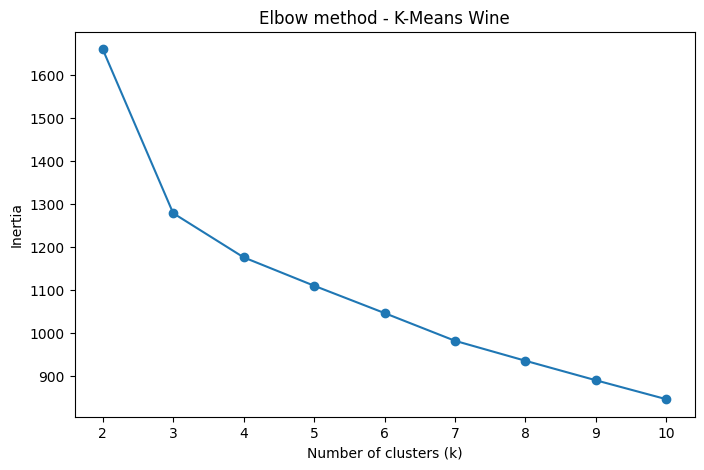

In [196]:
# Learning how many clusters do we need to aim for. Defining the k range and collecitng innertia

inertia = []

K = range(2, 11)

for k in K:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Plotting Elbow method
plt.figure(figsize=(8, 5))
plt.plot(K, inertia, marker = 'o')

plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow method - K-Means Wine')

plt.show()

In [197]:
# Quantifying intertia
for k in range(1, len(inertia)):
    improvement = inertia[k-1] - inertia[k]
    improvement_pct = improvement / inertia[k-1]*100

    print(
    f'k={k} to k={k+1}:'
        f'{improvement:.2f}'
        f'({improvement_pct:.2f}%)'
    )

k=1 to k=2:380.83(22.96%)
k=2 to k=3:102.50(8.02%)
k=3 to k=4:65.92(5.61%)
k=4 to k=5:63.51(5.72%)
k=5 to k=6:64.41(6.16%)
k=6 to k=7:46.39(4.73%)
k=7 to k=8:45.31(4.84%)
k=8 to k=9:44.00(4.94%)


In [198]:
# Silhouette_scores

silhouette_scores = []
K = range(2, 11)

for k in K:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_scaled)
    
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)
    
    print(f"k={k}: {score:.3f}")
    

k=2: 0.259
k=3: 0.285
k=4: 0.260
k=5: 0.202
k=6: 0.237
k=7: 0.204
k=8: 0.157
k=9: 0.150
k=10: 0.144


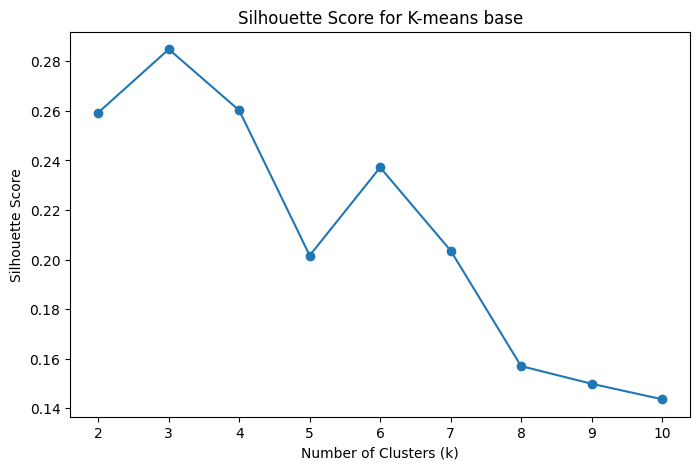

In [199]:
#Plotting the silhouette score
plt.figure(figsize=(8, 5))

plt.plot(K,
         silhouette_scores, 
         marker= 'o'
)

plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score for K-means base')
plt.show()

**Results:** 
* Elbow results show k= 3 as a winner and intertia results show the Silhouette Score: highest at k=3 (0.285) with another peak at k=4 (0.260). Overall low score suggest that cluster are overlapping wihtout forming a clearly separated segments. 

The results indicate that assignment is done appropriate and cluster k = 3 is the closest to score 1, distincting from other cluster numbers. However, the maximium score is only 0.285 indicating that wine categories do not form three extremely distinct segments, naturally separated, and there may be a moderate separatrtion, and an overlap between clusters.

### 7.2. Fitting the model (k=3)

In [200]:
# Fitting the k-means cluster (k = 3)

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
) 

cluster_labels = kmeans.fit_predict(X_scaled)

In [201]:
# Attaching labels to the original clean data file

df_wine_clustered = df_wine_clean.copy()
df_wine_clustered['cluster'] = cluster_labels

df_wine_clustered.head()

,Wine,Alcohol,Malic.acid,Ash,Acl,Mg,Phenols,Flavanoids,Nonflavanoid.phenols,Proanth,Color.int,Hue,OD,Proline,cluster
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065,2
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050,2
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185,2
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480,2
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735,2


In [202]:
#Count cluster size
df_wine_clustered['cluster'].value_counts().sort_index()

cluster
0    65
1    51
2    62
Name: count, dtype: int64

In [203]:
#Cluster procentages
df_wine_clustered['cluster'].value_counts(normalize=True).mul(100).round(1)

cluster
0    36.5
2    34.8
1    28.7
Name: proportion, dtype: float64

### 7.3. Cluster Profiling

In [ ]:
#Connecting to cluster profiles
cluster_profile = (
    df_wine_clustered
    .groupby('cluster')[features]
    .agg(['mean', 'median'])
    .round(2)
)

cluster_profile


Alcohol        Malic.acid          Ash           Acl             Mg  \
           mean median       mean median  mean median   mean median    mean   
cluster                                                                       
0         12.25  12.25       1.90   1.61  2.23   2.24  20.06   20.0   92.74   
1         13.13  13.11       3.31   3.27  2.42   2.38  21.24   21.0   98.67   
2         13.68  13.74       2.00   1.76  2.47   2.45  17.46   17.0  107.97   

                ... Proanth        Color.int          Hue           OD         \
        median  ...    mean median      mean median  mean median  mean median   
cluster         ...                                                             
0         88.0  ...    1.62   1.56      2.97    2.9  1.06   1.04  2.80   2.84   
1         97.0  ...    1.15   1.10      7.23    7.3  0.69   0.67  1.70   1.68   
2        105.5  ...    1.92   1.90      5.45    5.4  1.07   1.07  3.16   3.17   

         Proline          
            mean  median  
cluster                   
0         510.17   495.0  
1         619.06   620.0  
2        1100.23  1072.5  

[3 rows x 26 columns]

In [217]:
#Connecting to cluster profiles
cluster_profile = (
    df_wine_clustered
    .groupby('cluster')[features]
    .agg(['median'])
    .round(2)
)

cluster_profile

,Alcohol,Malic.acid,Ash,Acl,Mg,Phenols,Flavanoids,Nonflavanoid.phenols,Proanth,Color.int,Hue,OD,Proline
,median,median,median,median,median,median,median,median,median,median,median,median,median
cluster,,,,,,,,,,,,,
0,12.25,1.61,2.24,20.0,88.0,2.20,2.03,0.35,1.56,2.9,1.04,2.84,495.0
1,13.11,3.27,2.38,21.0,97.0,1.65,0.70,0.47,1.10,7.3,0.67,1.68,620.0
2,13.74,1.76,2.45,17.0,105.5,2.82,2.98,0.29,1.90,5.4,1.07,3.17,1072.5


**Cluster 0:** Charactarised by relatively lower Color.int and Alcohol with many other characteristics closer to the averaga dataset

**Cluster 1:** Charactarised by higher Color.int and Malic Acid AND alongside lower OD and Flavonoids and Phenols

**Cluster 2:** Charactarised by higher values of Alcohol, Mg, Flavoinoids, Proline, AND lower Acl

In [ ]:
#Optional: Cluster medians

scaled_profile = X_scaled.copy()
scaled_profile['cluster'] = cluster_labels

cluster_scaled_medians = (scaled_profile
    .groupby('cluster')
    .median()
)

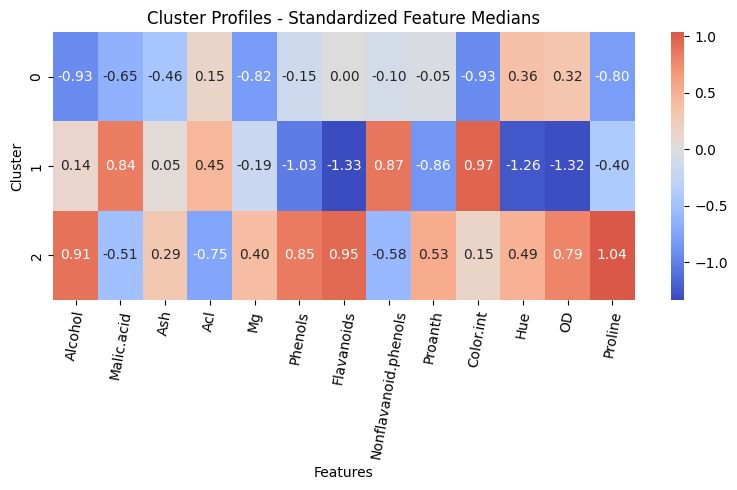

In [ ]:
# Optional: Heatmap of cluster medians on standardised scale
plt.figure(figsize=(8, 5))

sns.heatmap(
    cluster_scaled_medians,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0
)
plt.xticks(rotation=80)
plt.title('Cluster Profiles - Standardized Feature Medians')
plt.xlabel('Features')
plt.ylabel('Cluster')

plt.tight_layout()
plt.show()


### 7.4. Wine category profiles 
Connecting back to the original Wine category

In [ ]:
#Crosschecking createrd clusters with Wine feature

wine_cluster_comparison = pd.crosstab(df_wine_clustered['Wine'], df_wine_clustered['cluster'])

wine_cluster_comparison

cluster,0,1,2
Wine,,,
1,0,0,59
2,65,3,3
3,0,48,0


**RESULT:**

Unsupervised K_means show a striong correspondence with the known Wine categories. All observation that belongs to Wine 1 and Wine 3 were grouped consistently into respective cluster. Wine 2 showed less separation, with 6 observations assigned outside its dominant clusterm, 3 of each of the cluster. Wine 2 shows indicates more overlapp between categories whereas Wine 1 and 3 appear more distinctly separated in standardised feature space.
